In [80]:
# Setup Python path for src module imports
import pandas as pd
import sys
from pathlib import Path

project_root = Path.cwd().resolve().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.data_preprocessing import preprocess_it_dataset
from src.feature_engineering import create_all_features
from src.config import PROCESSED_DATA_DIR, FIGURES_DIR

In [81]:
df = preprocess_it_dataset("IT_SystemPerformanceAndResourceMetricsDataset.csv")


Loading Dataset
Dataset Loaded Successfully
Rows    : 100000
Columns : 12

Dataset Summary
<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   cpu_utilization    100000 non-null  float64
 1   memory_usage       100000 non-null  float64
 2   disk_io            100000 non-null  float64
 3   network_latency    100000 non-null  float64
 4   process_count      100000 non-null  float64
 5   thread_count       100000 non-null  float64
 6   context_switches   100000 non-null  float64
 7   cache_miss_rate    100000 non-null  float64
 8   temperature        100000 non-null  float64
 9   power_consumption  100000 non-null  float64
 10  uptime             100000 non-null  float64
 11  status             100000 non-null  int64  
dtypes: float64(11), int64(1)
memory usage: 9.2 MB
None

Missing Values
cpu_utilization      0
memory_usage         0
disk_

In [82]:
df = create_all_features(df)

In [83]:
print(df.columns)

Index(['cpu_utilization', 'memory_usage', 'disk_io', 'network_latency',
       'process_count', 'thread_count', 'context_switches', 'cache_miss_rate',
       'temperature', 'power_consumption', 'uptime', 'status',
       'resource_stress_index', 'cpu_memory_ratio', 'disk_pressure',
       'context_switch_density', 'cache_efficiency', 'thermal_stress'],
      dtype='str')


In [84]:
# Test the Module
df = preprocess_it_dataset("IT_SystemPerformanceAndResourceMetricsDataset.csv")

df = create_all_features(df)

print(df.head())

print(df.info())


Loading Dataset
Dataset Loaded Successfully
Rows    : 100000
Columns : 12

Dataset Summary
<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   cpu_utilization    100000 non-null  float64
 1   memory_usage       100000 non-null  float64
 2   disk_io            100000 non-null  float64
 3   network_latency    100000 non-null  float64
 4   process_count      100000 non-null  float64
 5   thread_count       100000 non-null  float64
 6   context_switches   100000 non-null  float64
 7   cache_miss_rate    100000 non-null  float64
 8   temperature        100000 non-null  float64
 9   power_consumption  100000 non-null  float64
 10  uptime             100000 non-null  float64
 11  status             100000 non-null  int64  
dtypes: float64(11), int64(1)
memory usage: 9.2 MB
None

Missing Values
cpu_utilization      0
memory_usage         0
disk_

In [85]:
# Load cleaned data using config paths
# import pandas as pd
# from src.config import PROCESSED_DATA_DIR, FIGURES_DIR

# df = pd.read_csv(
#     PROCESSED_DATA_DIR / "cleaned_dataset.csv"
# )

# df.head()

In [89]:
# Feature 10 — Encoding

from sklearn.preprocessing import LabelEncoder

if "risk_level" not in df.columns:
    if "risk_score" not in df.columns:
        df["risk_score"] = (
            0.35*(df["cpu_utilization"]/100)
            +
            0.30*(df["memory_usage"]/100)
            +
            0.20*(df["network_latency"]/200)
            +
            0.15*(df["disk_io"]/100)
        )

    def assign_risk(score):
        if score < 0.40:
            return "Low"
        elif score < 0.70:
            return "Medium"
        else:
            return "High"

    df["risk_level"] = df["risk_score"].apply(assign_risk)

le = LabelEncoder()

df["risk_label"] = (
    le.fit_transform(
        df["risk_level"]
    )
)

Scaling

In [90]:
from sklearn.preprocessing import StandardScaler

features = [
    'cpu_utilization',
    'memory_usage',
    'disk_io',
    'network_latency',
    'process_count',
    'thread_count',
    'context_switches',
    'cache_miss_rate',
    'temperature',
    'power_consumption',
    'uptime',
    'resource_stress_index',
    'cpu_memory_ratio',
    'disk_pressure',
    'context_switch_density',
    'cache_efficiency',
    'thermal_stress'
]

scaler = StandardScaler()

df_scaled = scaler.fit_transform(
    df[features]
)

PCA Visualization

In [91]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

pca_result = pca.fit_transform(df_scaled)

pca_df = pd.DataFrame(
    pca_result,
    columns=["PC1","PC2"]
)

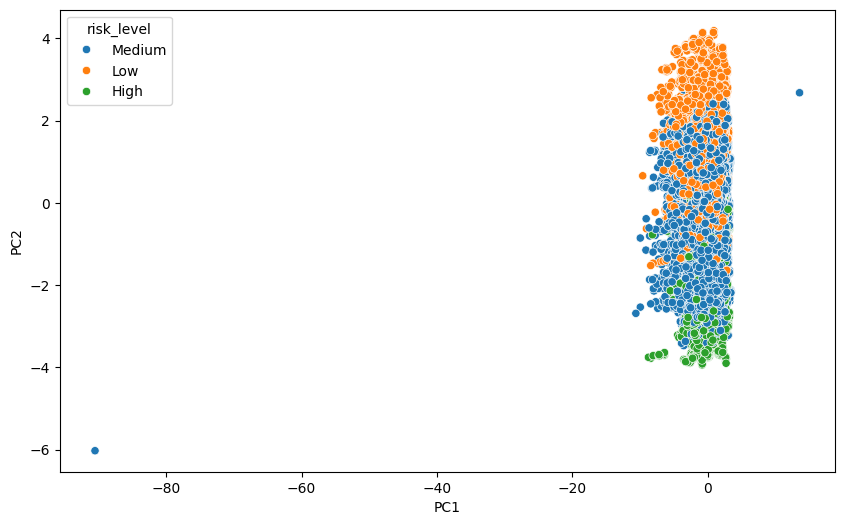

In [92]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue=df["risk_level"]
)

# PCA Plot using config path
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
plt.savefig(
    FIGURES_DIR / "pca_visualization.png"
)

plt.show()

In [93]:
df.to_csv(
    PROCESSED_DATA_DIR / "feature_engineered_dataset.csv",
    index=False
)

In [94]:
df["status"].value_counts()

status
0    98990
1     1010
Name: count, dtype: int64

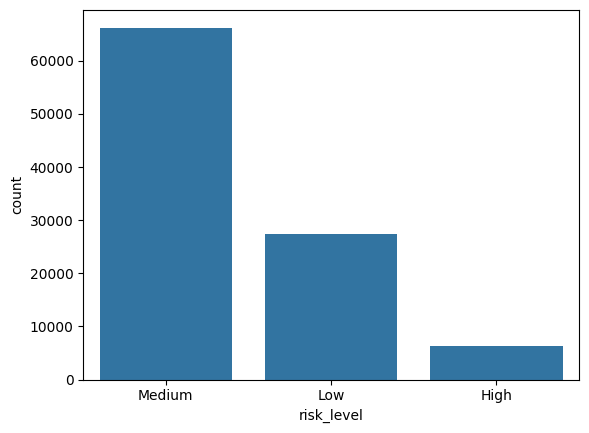

In [95]:
# Risk Distribution Plot using config path
sns.countplot(
    data=df,
    x="risk_level"
)

plt.savefig(
    FIGURES_DIR / "risk_distribution.png"
)

In [96]:
print(df["risk_level"].value_counts())

risk_level
Medium    66258
Low       27342
High       6400
Name: count, dtype: int64


In [97]:
df["risk_level"].value_counts()

risk_level
Medium    66258
Low       27342
High       6400
Name: count, dtype: int64

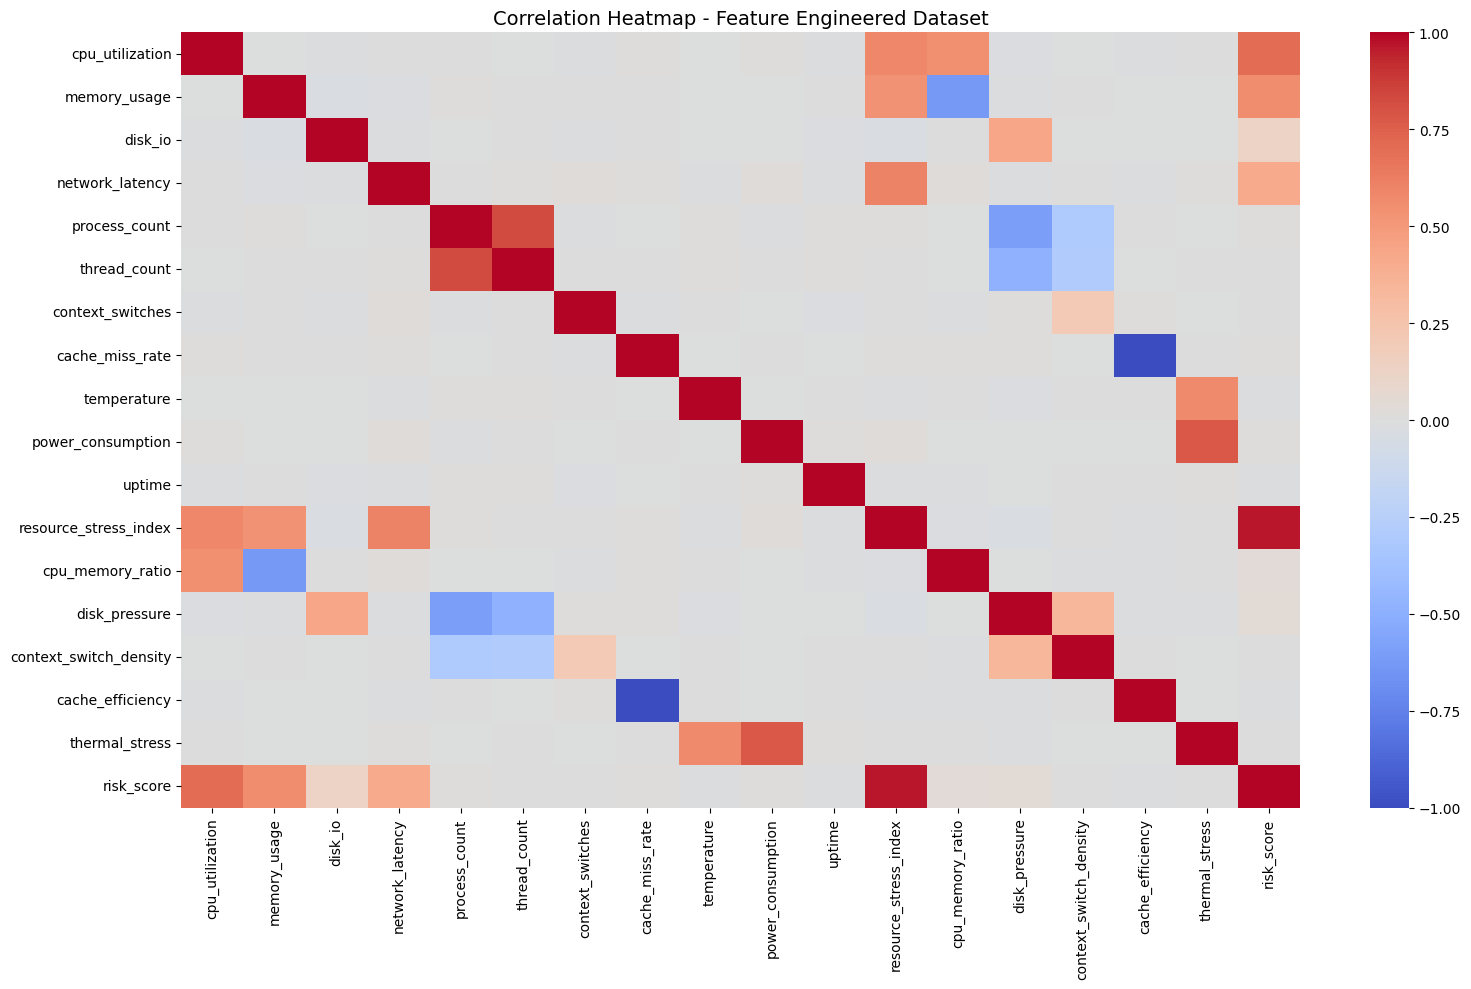

In [98]:
# Heatmap 2 — Feature Engineered Dataset

feature_cols = [
    'cpu_utilization',
    'memory_usage',
    'disk_io',
    'network_latency',
    'process_count',
    'thread_count',
    'context_switches',
    'cache_miss_rate',
    'temperature',
    'power_consumption',
    'uptime',
    'resource_stress_index',
    'cpu_memory_ratio',
    'disk_pressure',
    'context_switch_density',
    'cache_efficiency',
    'thermal_stress',
    'risk_score'
]

corr_matrix = df[feature_cols].corr()

plt.figure(figsize=(16,10))

sns.heatmap(
    corr_matrix,
    annot=False,
    cmap="coolwarm",
    center=0
)

plt.title(
    "Correlation Heatmap - Feature Engineered Dataset",
    fontsize=14
)

plt.tight_layout()

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
plt.savefig(
    FIGURES_DIR / "correlation_heatmap_feature_engineered.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

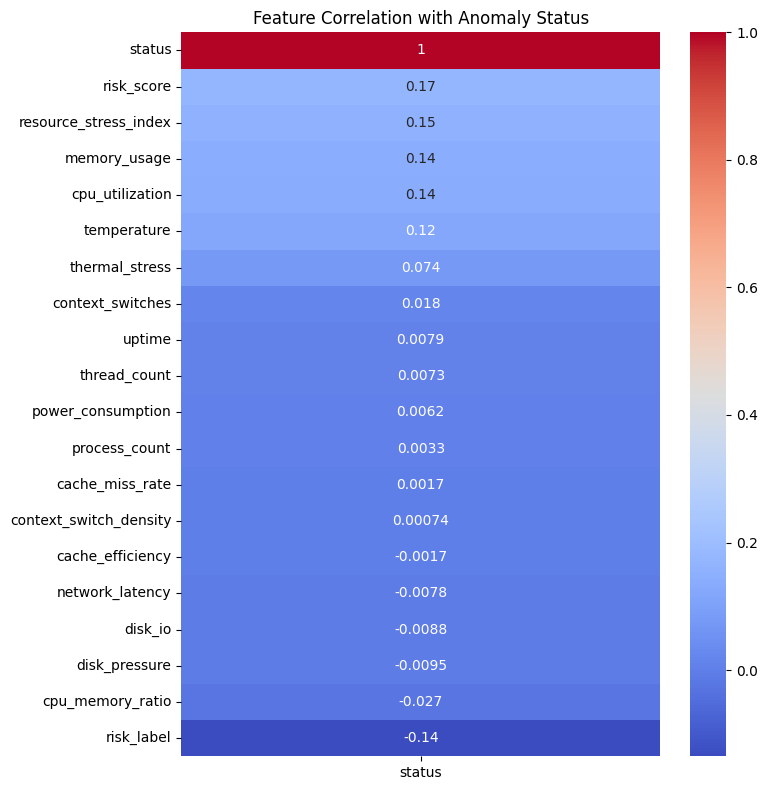

In [99]:
# Generate a heatmap showing correlation with anomaly status

status_corr = (
    df.select_dtypes(include=['number'])
      .corr()['status']
      .sort_values(ascending=False)
)

plt.figure(figsize=(8,8))

sns.heatmap(
    status_corr.to_frame(),
    annot=True,
    cmap="coolwarm"
)

plt.title(
    "Feature Correlation with Anomaly Status"
)

plt.tight_layout()

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
plt.savefig(
    FIGURES_DIR / "status_correlation_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()